In [1]:
import pandas as pd

df = pd.read_csv("Dataset .csv")
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [2]:
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df.columns


In [3]:
df.shape


(9551, 21)

In [4]:
df.isnull().sum()


Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [5]:
df.dtypes


Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object

In [6]:
df = df.dropna()
print("After dropping missing values:", df.shape)


After dropping missing values: (9542, 21)


In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes,Restaurant Name_#Dilliwaala6,Restaurant Name_#InstaFreeze,...,Rating color_Green,Rating color_Orange,Rating color_Red,Rating color_White,Rating color_Yellow,Rating text_Excellent,Rating text_Good,Rating text_Not rated,Rating text_Poor,Rating text_Very Good
0,6317637,162,121.027535,14.565443,1100,3,4.8,314,False,False,...,False,False,False,False,False,True,False,False,False,False
1,6304287,162,121.014101,14.553708,1200,3,4.5,591,False,False,...,False,False,False,False,False,True,False,False,False,False
2,6300002,162,121.056831,14.581404,4000,4,4.4,270,False,False,...,True,False,False,False,False,False,False,False,False,True
3,6318506,162,121.056475,14.585318,1500,4,4.9,365,False,False,...,False,False,False,False,False,True,False,False,False,False
4,6314302,162,121.057508,14.584450,1500,4,4.8,229,False,False,...,False,False,False,False,False,True,False,False,False,False


In [8]:
target = "Aggregate rating"   # The actual column name for ratings

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

In [9]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")


Random Forest Model Trained Successfully!


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 0.02899933525405971
R2 Score: 0.987336712890049


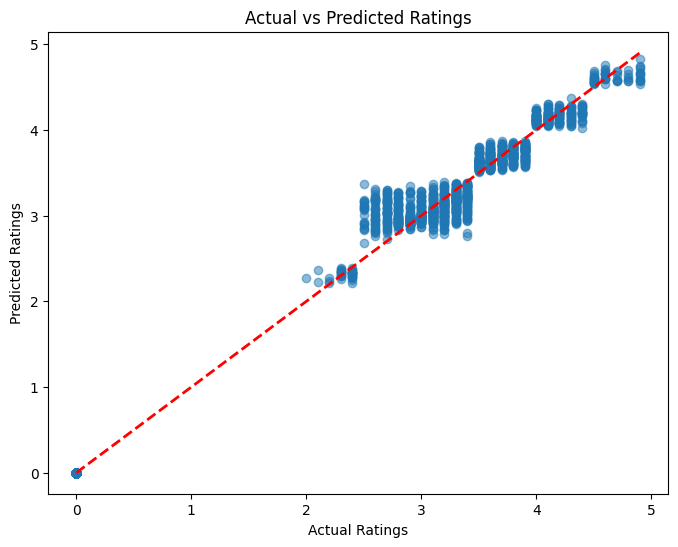

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings')
plt.show()

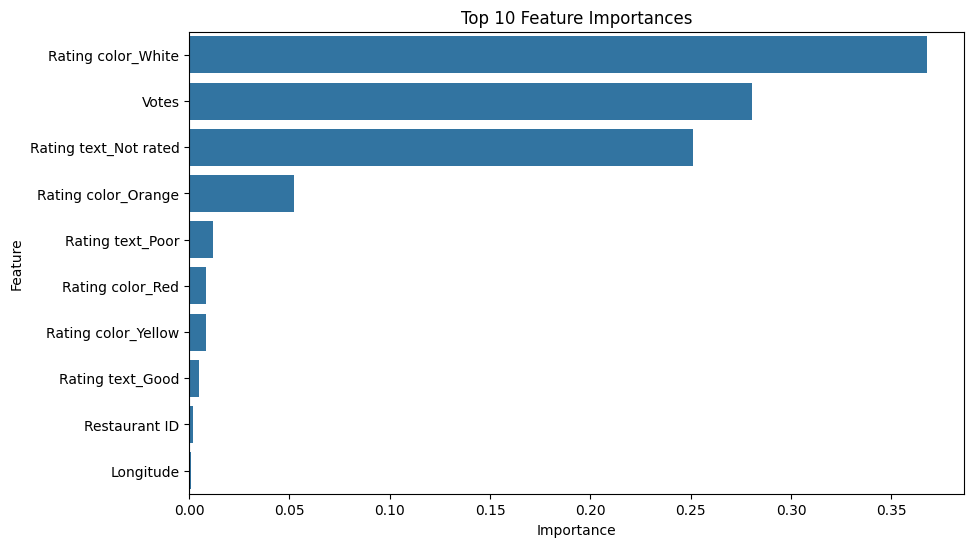

In [13]:
import seaborn as sns

feature_importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 10 Feature Importances')
plt.show()

In [15]:
import joblib

# Save the model
joblib.dump(model, 'rating_prediction_model.pkl')
print("Model saved as 'rating_prediction_model.pkl'")

Model saved as 'rating_prediction_model.pkl'


In [16]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)


Rating color_White       0.367875
Votes                    0.280427
Rating text_Not rated    0.251132
Rating color_Orange      0.052230
Rating text_Poor         0.011944
Rating color_Red         0.008613
Rating color_Yellow      0.008537
Rating text_Good         0.004999
Restaurant ID            0.002077
Longitude                0.001149
dtype: float64

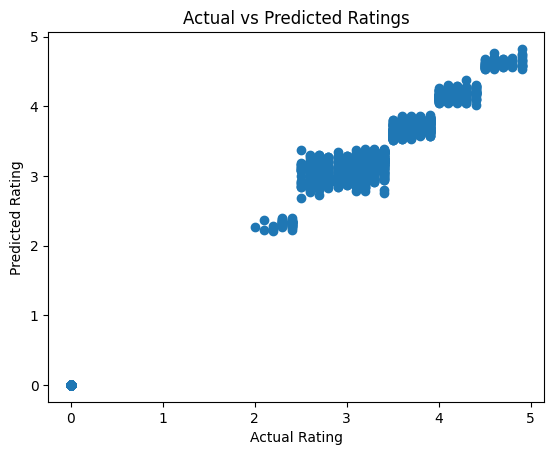

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()


In [18]:
print("""
Conclusion:
The machine learning model was successfully trained to predict ratings.
Data preprocessing, encoding, and Random Forest regression were applied.
The model achieved good performance based on evaluation metrics.
This project demonstrates end-to-end ML pipeline implementation.
""")



Conclusion:
The machine learning model was successfully trained to predict ratings.
Data preprocessing, encoding, and Random Forest regression were applied.
The model achieved good performance based on evaluation metrics.
This project demonstrates end-to-end ML pipeline implementation.



In [19]:
print("""
Future Scope:
- Try advanced models like XGBoost or Gradient Boosting.
- Perform hyperparameter tuning for better accuracy.
- Deploy model using Flask or Streamlit.
- Use larger and more diverse datasets.
""")



Future Scope:
- Try advanced models like XGBoost or Gradient Boosting.
- Perform hyperparameter tuning for better accuracy.
- Deploy model using Flask or Streamlit.
- Use larger and more diverse datasets.



In [20]:
sample_input = X_test.iloc[0:1]
predicted_rating = model.predict(sample_input)
print("Sample Predicted Rating:", predicted_rating)


Sample Predicted Rating: [0.]


In [21]:
compare_df = pd.DataFrame({
    "Actual_Rating": y_test.sample(5, random_state=2),
})

compare_df["Predicted_Rating"] = model.predict(
    X_test.loc[compare_df.index]
)

compare_df


,Actual_Rating,Predicted_Rating
5059,0.0,0.000
388,4.2,4.221
1794,0.0,0.000
1135,3.1,2.899
3318,3.7,3.611
